In [ ]:
from google.colab import drive
drive.mount('/content/drive')
# connecting to google drive to import data set

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score, classification_report, confusion_matrix,
    RocCurveDisplay, precision_recall_fscore_support,average_precision_score,PrecisionRecallDisplay,
    f1_score,mean_squared_error, mean_absolute_error, r2_score
)


from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Speed Dating Data.csv', encoding="ISO-8859-1")

# exploring data

print(f"Dataset size: {df.shape}")
print(f"Target distribution: {df[['match']].value_counts(dropna=False)}")
print(f"Categories:{df.columns[:30]}")
df.head()

Dataset size: (8378, 195)
Target distribution: match
0        6998
1        1380
Name: count, dtype: int64
Categories:Index(['iid', 'id', 'gender', 'idg', 'condtn', 'wave', 'round', 'position',
       'positin1', 'order', 'partner', 'pid', 'match', 'int_corr', 'samerace',
       'age_o', 'race_o', 'pf_o_att', 'pf_o_sin', 'pf_o_int', 'pf_o_fun',
       'pf_o_amb', 'pf_o_sha', 'dec_o', 'attr_o', 'sinc_o', 'intel_o', 'fun_o',
       'amb_o', 'shar_o'],
      dtype='object')


,iid,id,gender,idg,condtn,wave,round,position,positin1,order,...,attr3_3,sinc3_3,intel3_3,fun3_3,amb3_3,attr5_3,sinc5_3,intel5_3,fun5_3,amb5_3
0,1,1.0,0,1,1,1,10,7,NaN,4,...,5.0,7.0,7.0,7.0,7.0,NaN,NaN,NaN,NaN,NaN
1,1,1.0,0,1,1,1,10,7,NaN,3,...,5.0,7.0,7.0,7.0,7.0,NaN,NaN,NaN,NaN,NaN
2,1,1.0,0,1,1,1,10,7,NaN,10,...,5.0,7.0,7.0,7.0,7.0,NaN,NaN,NaN,NaN,NaN
3,1,1.0,0,1,1,1,10,7,NaN,5,...,5.0,7.0,7.0,7.0,7.0,NaN,NaN,NaN,NaN,NaN
4,1,1.0,0,1,1,1,10,7,NaN,7,...,5.0,7.0,7.0,7.0,7.0,NaN,NaN,NaN,NaN,NaN


In [ ]:
# key columms
key_cols = ["iid", "wave", "match"]
for c in key_cols:
    assert c in df.columns, f"Missing key column: {c}"

# timeline

time_cols = [c for c in ["iid", "wave", "round", "order"] if c in df.columns]
df = df.sort_values(time_cols).reset_index(drop=True)
print(time_cols)

['iid', 'wave', 'round', 'order']


In [ ]:
# missing data percentage
missing_pct = df.isna().mean().sort_values(ascending=False)
high_missing_cols = missing_pct[missing_pct > 0.50].index.tolist()
high_missing_cols = [c for c in high_missing_cols if c not in key_cols]

df_clean = df.drop(columns=high_missing_cols).copy()

print("Dropped columns (>50% missing):", len(high_missing_cols))
print("Shape after drop:", df_clean.shape)

Dropped columns (>50% missing): 59
Shape after drop: (8378, 136)


In [ ]:
# Column separation numeric/category
num_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in df_clean.columns if c not in num_cols]

# Imputation numeric=median, categorical=mode
for col in num_cols:
    if df_clean[col].isna().any():
        df_clean[col] = df_clean[col].fillna(df_clean[col].median())

for col in cat_cols:
    if df_clean[col].isna().any():
        mode_val = df_clean[col].mode(dropna=True)
        df_clean[col] = df_clean[col].fillna(mode_val.iloc[0] if len(mode_val) else "Unknown")

In [ ]:
# Outliers: IQR flag

def iqr_outlier_flag(s, k=1.5):
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    low, high = q1 - k*iqr, q3 + k*iqr
    return ((s < low) | (s > high)).astype(int)

outlier_dict = {}

for col in num_cols:
    if col in key_cols:
        continue
    if df_clean[col].nunique() > 10:
        outlier_dict[f"{col}_outlier"] = iqr_outlier_flag(df_clean[col])

#  Create a new DataFrame containing all the flags

outlier_df = pd.DataFrame(outlier_dict)

#Concatenate all DataFrames at once

df_clean = pd.concat([df_clean, outlier_df], axis=1)

print("Outlier flag columns created:", len(outlier_df.columns))



Outlier flag columns created: 82


In [ ]:
#Final check
print("Any NaNs left?", df_clean.isna().any().any())
print("Duplicates:", df_clean.duplicated().sum())

Any NaNs left? False
Duplicates: 0


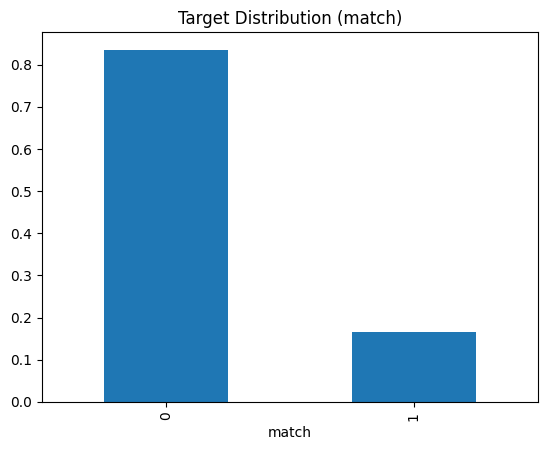

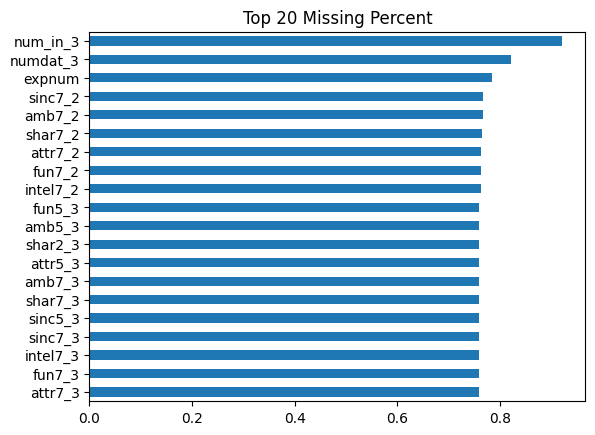

In [ ]:
# Target Distribution
df_clean["match"].value_counts(normalize=True).plot(kind="bar")
plt.title("Target Distribution (match)")
plt.show()

#  Missing categories - top 20
missing_pct.head(20).plot(kind="barh")
plt.title("Top 20 Missing Percent")
plt.gca().invert_yaxis()
plt.show()

 STAGE 3 — Feature Engineering (Lag + Rolling + Domain):

In [ ]:
# Common rating columns (if available)

rate_given = [c for c in ["attr","sinc","intel","fun","amb","shar"] if c in df_clean.columns]
rate_recv  = [c for c in ["attr_o","sinc_o","intel_o","fun_o","amb_o","shar_o"] if c in df_clean.columns]

# age diff
if "age" in df_clean.columns and "age_o" in df_clean.columns:
    df_clean["age_diff"] = (df_clean["age"] - df_clean["age_o"]).abs()

# average ratings
if rate_given:
    df_clean["avg_rating_given"] = df_clean[rate_given].mean(axis=1)
if rate_recv:
    df_clean["avg_rating_received"] = df_clean[rate_recv].mean(axis=1)

if "avg_rating_given" in df_clean.columns and "avg_rating_received" in df_clean.columns:
    df_clean["rating_balance"] = df_clean["avg_rating_given"] - df_clean["avg_rating_received"]

# same race
if "race" in df_clean.columns and "race_o" in df_clean.columns:
    df_clean["same_race"] = (df_clean["race"] == df_clean["race_o"]).astype(int)

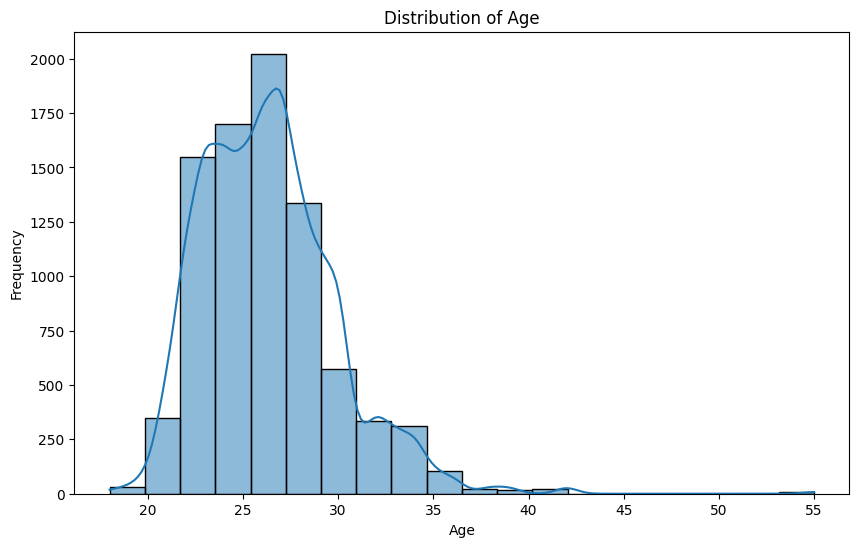

In [ ]:

# Distribution of Age
plt.figure(figsize=(10, 6))
sns.histplot(df_clean['age'], kde=True, bins=20)
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()


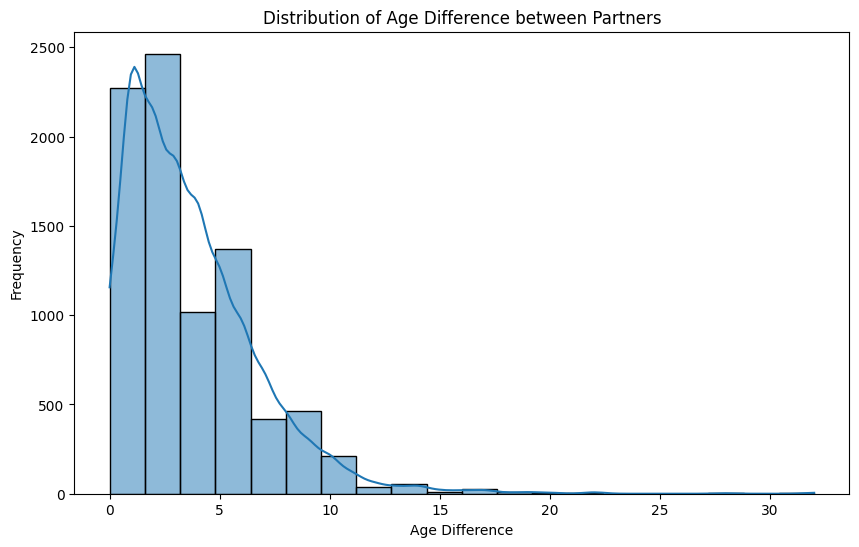

In [ ]:
# Distribution of Age Difference

if 'age_diff' in df_clean.columns:
    plt.figure(figsize=(10, 6))
    sns.histplot(df_clean['age_diff'], kde=True, bins=20)
    plt.title('Distribution of Age Difference between Partners')
    plt.xlabel('Age Difference')
    plt.ylabel('Frequency')
    plt.show()


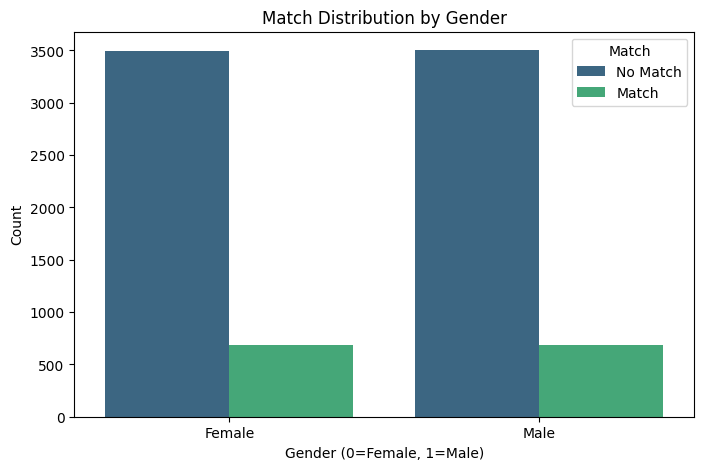

In [ ]:
# Match distribution by Gender
plt.figure(figsize=(8, 5))
sns.countplot(data=df_clean, x='gender', hue='match', palette='viridis')
plt.title('Match Distribution by Gender')
plt.xlabel('Gender (0=Female, 1=Male)')
plt.ylabel('Count')
plt.xticks(ticks=[0, 1], labels=['Female', 'Male'])
plt.legend(title='Match', labels=['No Match', 'Match'])
plt.show()


In [ ]:
#  Lag/Rolling features on 'match' within each iid


sort_cols = [c for c in ["iid","wave","round","order"] if c in df_clean.columns]
df_clean = df_clean.sort_values(sort_cols).reset_index(drop=True)


# Temporal features:
# match_lag1 = previous wave outcome
# match_roll_mean3 = short-term matching trend (last 3 waves)

df_clean["match_lag1"] = df_clean.groupby("iid")["match"].shift(1)
df_clean["match_lag1"] = df_clean["match_lag1"].fillna(0).astype(int)

df_clean["match_roll_mean3"] = (
    df_clean.groupby("iid")["match"]
    .shift(1)
    .rolling(3, min_periods=1)
    .mean()
    .reset_index(level=0, drop=True)
).fillna(0)


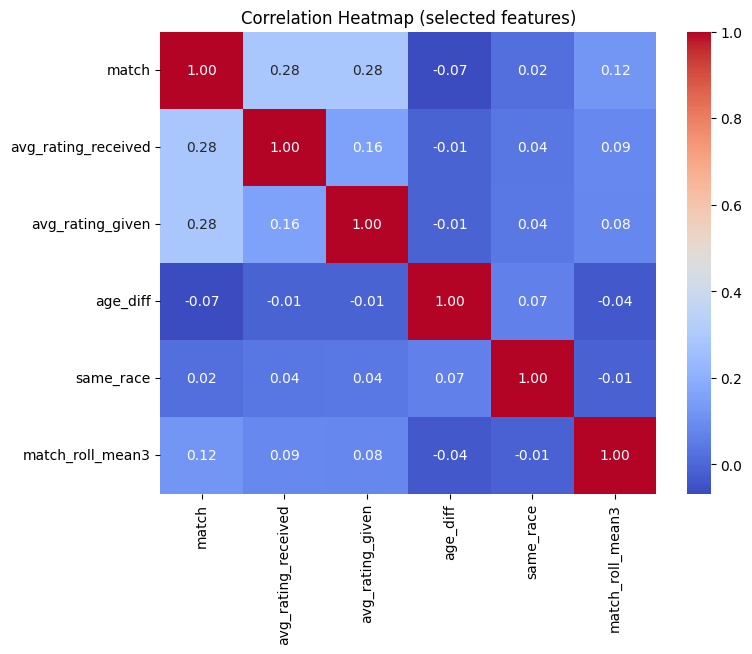

In [ ]:
# Correlation matrix of key features

corr_cols = [c for c in ["match","avg_rating_received","avg_rating_given","age_diff","same_race","match_roll_mean3"] if c in df_clean.columns]
corr = df_clean[corr_cols].corr(numeric_only=True)
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap (selected features)")
plt.show()

 STAGE 4 — Model Development (Pipelines + Group split)




In [ ]:
# Chronological Split

target = "match"

remove_cols = [
    "match",
    "match_lag1",
    "match_roll_mean3",
    "iid",
    "dec","dec_o",
    "like","like_o",
    "prob","prob_o",
    "met","met_o"
]

df_model = df_clean.dropna(subset=[target])
features = [c for c in df_model.columns if c not in remove_cols]

X = df_model[features]
y = df_model[target].astype(int)

# Chronological split
waves = sorted(df_model["wave"].unique())
split_idx = int(len(waves)*0.8)

train_waves = waves[:split_idx]
test_waves  = waves[split_idx:]

train_mask = df_model["wave"].isin(train_waves)
test_mask  = df_model["wave"].isin(test_waves)

X_train, X_test = X[train_mask], X[test_mask]
y_train, y_test = y[train_mask], y[test_mask]


In [ ]:
# Walk-Forward Cross Validation
def walk_forward(df, waves, min_train=6):
    for i in range(min_train, len(waves)-1):
        train_w = waves[:i]
        val_w   = [waves[i]]
        yield (
            df["wave"].isin(train_w),
            df["wave"].isin(val_w)
        )


In [ ]:
# Models + Rationale
# Random Forest
RandomForestClassifier(
    n_estimators=500,
    max_depth=8,
    min_samples_leaf=15,
    min_samples_split=30,
    max_features="sqrt",
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

RandomForestClassifier(class_weight='balanced', max_depth=8,
                       min_samples_leaf=15, min_samples_split=30,
                       n_estimators=500, n_jobs=-1, random_state=42)

Rationale:

Limited depth prevents overfitting.

Minimum leaf size stabilizes predictions.

Balanced class weighting handles class imbalance.

In [ ]:
# XGBoost
XGBClassifier(
    n_estimators=400,
    learning_rate=0.03,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=1.0,
    reg_lambda=3.0,
    scale_pos_weight=(y_train==0).sum()/(y_train==1).sum(),
    eval_metric="logloss",
    random_state=42
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.03, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=400, n_jobs=None,
              num_parallel_tree=None, ...)

Rationale:

Low learning rate improves generalization.

Shallow trees prevent overfitting.

L1 & L2 regularization penalize complexity.

Subsampling increases robustness.

In [ ]:
# LightGBM
LGBMClassifier(
    n_estimators=400,
    learning_rate=0.03,
    num_leaves=25,
    min_data_in_leaf=60,
    feature_fraction=0.8,
    bagging_fraction=0.8,
    class_weight="balanced",
    random_state=42
)

LGBMClassifier(bagging_fraction=0.8, class_weight='balanced',
               feature_fraction=0.8, learning_rate=0.03, min_data_in_leaf=60,
               n_estimators=400, num_leaves=25, random_state=42)

Rationale:

Controlled leaf size limits tree complexity.

Feature and row sampling reduce variance.

Designed for efficiency with high-dimensional data.

In [ ]:
# Define the preprocessing steps for numerical and categorical features
numeric_transformer = Pipeline(steps=[('scaler', StandardScaler())])
categorical_transformer = Pipeline(steps=[('onehot', OneHotEncoder(handle_unknown='ignore'))])

# Get numerical and categorical feature names after dropping target and other columns
# Filter out 'iid', 'wave' from features if they are numeric as they are used for splitting
features_for_preprocessing = [f for f in features if f not in ['iid', 'wave']]

# Re-determine num_cols and cat_cols based on the `features` list used for X
num_features_in_X = X[features_for_preprocessing].select_dtypes(include=np.number).columns.tolist()
cat_features_in_X = X[features_for_preprocessing].select_dtypes(include='object').columns.tolist()


preprocess = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_features_in_X),
        ('cat', categorical_transformer, cat_features_in_X)
    ],
    remainder='passthrough'
)


# Define the models
models = {
    "RandomForest": RandomForestClassifier(
        n_estimators=500,
        max_depth=8,
        min_samples_leaf=15,
        min_samples_split=30,
        max_features="sqrt",
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),
    "XGBoost": XGBClassifier(
        n_estimators=400,
        learning_rate=0.03,
        max_depth=3,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=1.0,
        reg_lambda=3.0,
        scale_pos_weight=(y_train==0).sum()/(y_train==1).sum(),
        eval_metric="logloss",
        random_state=42
    ),
    "LightGBM": LGBMClassifier(
        n_estimators=400,
        learning_rate=0.03,
        num_leaves=25,
        min_data_in_leaf=60,
        feature_fraction=0.8,
        bagging_fraction=0.8,
        class_weight="balanced",
        random_state=42
    )
}


cv_results = {}

for name, model in models.items():

    aucs = []

    for tr_mask, val_mask in walk_forward(df_model, train_waves):

        pipe = Pipeline([
            ("prep", preprocess),
            ("clf", model)
        ])

        pipe.fit(X[tr_mask], y[tr_mask])
        prob = pipe.predict_proba(X[val_mask])[:,1]

        aucs.append(roc_auc_score(y[val_mask], prob))

    cv_results[name] = np.mean(aucs)



[LightGBM] [Warning] min_data_in_leaf is set=60, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=60
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] min_data_in_leaf is set=60, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=60
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Info] Number of positive: 344, number of negative: 1552
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002174 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `fo

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] min_data_in_leaf is set=60, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=60
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] min_data_in_leaf is set=60, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=60
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] min_data_in_leaf is set=60, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=60
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] min_data_in_leaf is set=60, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=60
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] min_data_in_leaf is set=60, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=60
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] min_data_in_leaf is set=60, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=60
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging

...

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] min_data_in_leaf is set=60, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=60
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] min_data_in_leaf is set=60, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=60
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] min_data_in_leaf is set=60, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=60
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] min_data_in_leaf is set=60, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=60
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] min_data_in_leaf is set=60, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=60
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] min_data_in_leaf is set=60, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=60
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [ ]:
# Final Test Evaluation

test_results = {}

for name, model in models.items():

    pipe = Pipeline([
        ("prep", preprocess),
        ("clf", model)
    ])

    pipe.fit(X_train, y_train)
    probs = pipe.predict_proba(X_test)[:,1]

    test_results[name] = roc_auc_score(y_test, probs)


[LightGBM] [Warning] min_data_in_leaf is set=60, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=60
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] min_data_in_leaf is set=60, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=60
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Info] Number of positive: 1098, number of negative: 5426
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.007844 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `f

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] min_data_in_leaf is set=60, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=60
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] min_data_in_leaf is set=60, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=60
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Info] Number of positive: 1098, number of negative: 5426
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.007728 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `f

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


<Figure size 800x600 with 0 Axes>

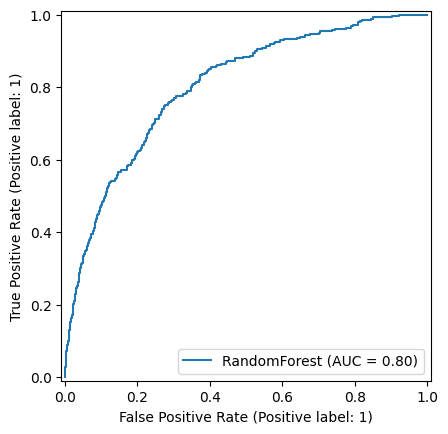

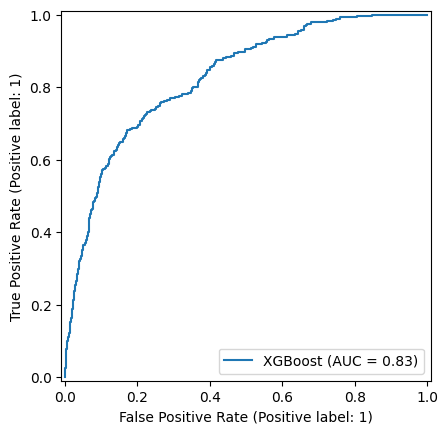

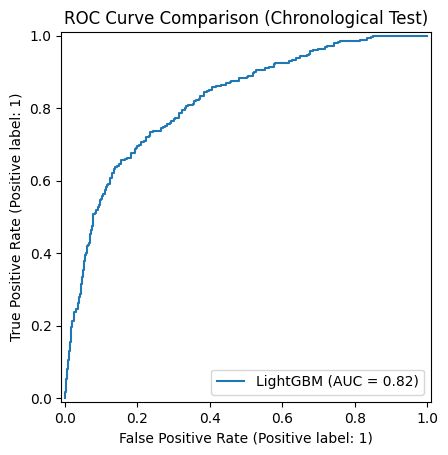

In [ ]:
# ROC curve
plt.figure(figsize=(8,6))

for name, model in models.items():
    pipe = Pipeline([("prep", preprocess), ("clf", model)])
    pipe.fit(X_train, y_train)
    RocCurveDisplay.from_estimator(pipe, X_test, y_test, name=name)

plt.title("ROC Curve Comparison (Chronological Test)")
plt.show()


Stage 5 - Variable Importance

[LightGBM] [Warning] min_data_in_leaf is set=60, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=60
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] min_data_in_leaf is set=60, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=60
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Info] Number of positive: 1098, number of negative: 5426
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.007639 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `f

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


<Figure size 800x600 with 0 Axes>

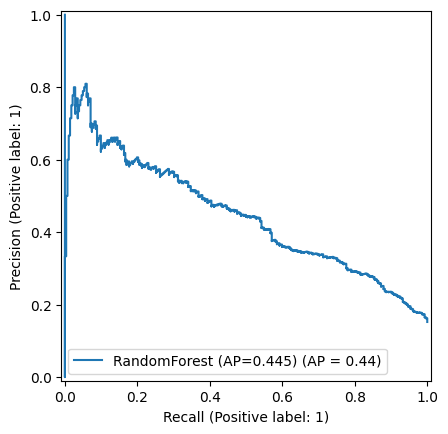

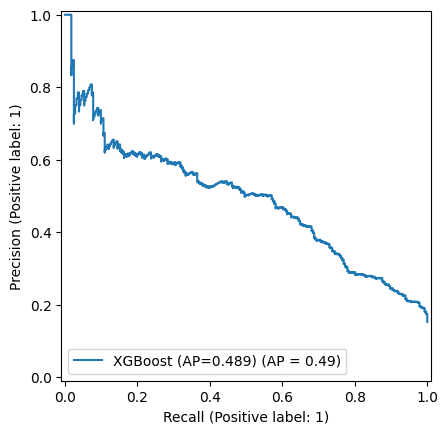

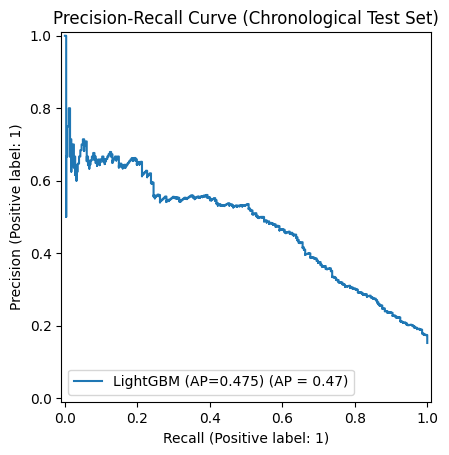

In [ ]:
# Precision-Recall Curve Analysis

plt.figure(figsize=(8,6))

pr_results = {}

for name, model in models.items():

    # Recreate pipeline exactly like Stage 4
    pipe = Pipeline([
        ("prep", preprocess),
        ("clf", model)
    ])

    pipe.fit(X_train, y_train)

    # Predict probabilities on chronological test set
    probs = pipe.predict_proba(X_test)[:,1]

    # Compute Average Precision (area under PR curve)
    ap = average_precision_score(y_test, probs)
    pr_results[name] = ap

    # Plot curve
    PrecisionRecallDisplay.from_estimator(
        pipe,
        X_test,
        y_test,
        name=f"{name} (AP={ap:.3f})"
    )

plt.title("Precision-Recall Curve (Chronological Test Set)")
plt.show()


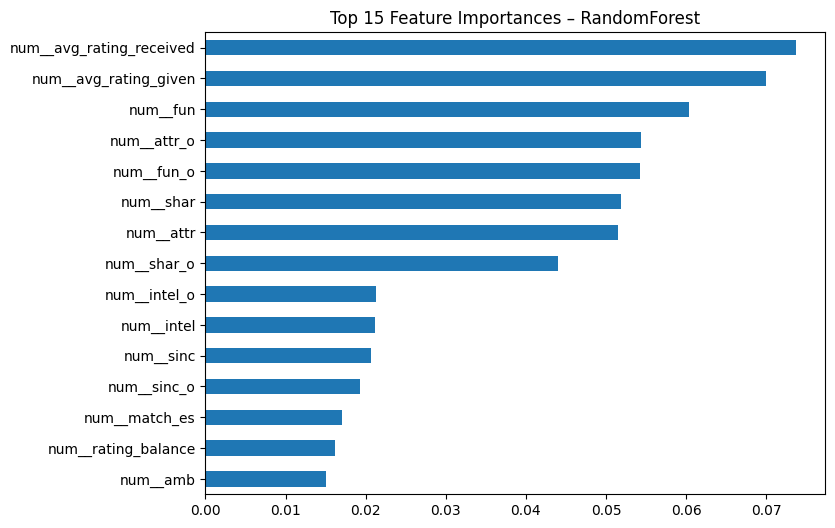

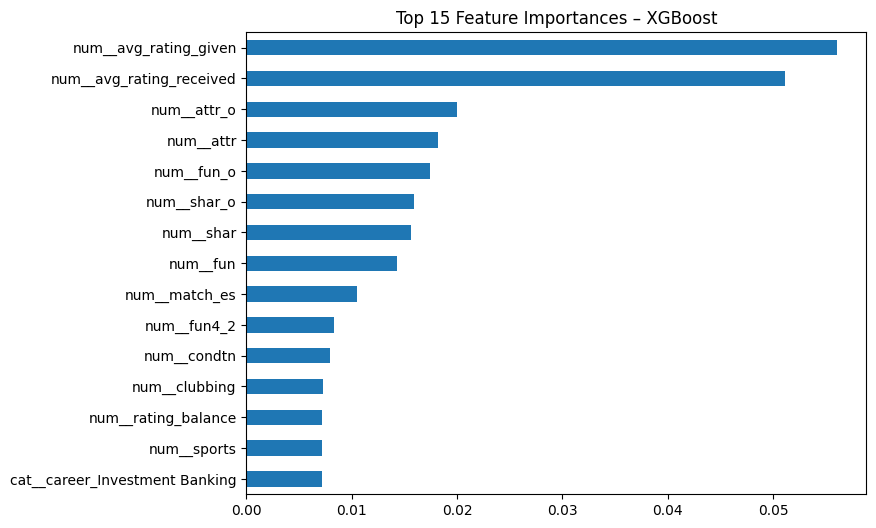

[LightGBM] [Warning] min_data_in_leaf is set=60, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=60
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] min_data_in_leaf is set=60, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=60
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Info] Number of positive: 1098, number of negative: 5426
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.035819 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `f

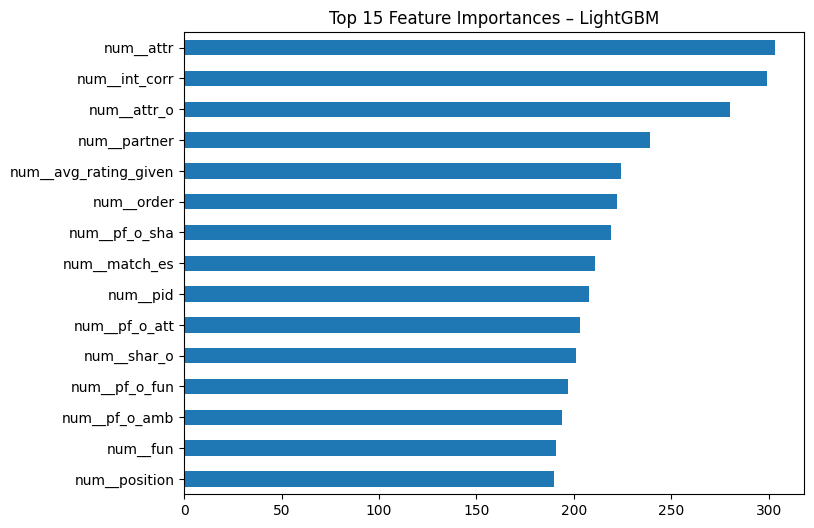

In [ ]:
# Feature Importance Analysis

for name, model in models.items():

    pipe = Pipeline([
        ("prep", preprocess),
        ("clf", model)
    ])

    pipe.fit(X_train, y_train)

    # Extract trained model
    trained_model = pipe.named_steps["clf"]

    # Get feature names after preprocessing
    feature_names = pipe.named_steps["prep"].get_feature_names_out()

    # Some models store importance differently
    if hasattr(trained_model, "feature_importances_"):
        importances = trained_model.feature_importances_
    else:
        continue

    fi = pd.Series(importances, index=feature_names)
    top_features = fi.nlargest(15)

    plt.figure(figsize=(8,6))
    top_features.sort_values().plot(kind="barh")
    plt.title(f"Top 15 Feature Importances – {name}")
    plt.show()


In [ ]:
# Threshold Optimization

threshold_results = {}

for name, model in models.items():

    pipe = Pipeline([
        ("prep", preprocess),
        ("clf", model)
    ])

    pipe.fit(X_train, y_train)
    probs = pipe.predict_proba(X_test)[:,1]

    best_threshold = 0
    best_f1 = 0

    for t in np.arange(0.1, 0.9, 0.01):
        preds = (probs >= t).astype(int)
        score = f1_score(y_test, preds)

        if score > best_f1:
            best_f1 = score
            best_threshold = t

    threshold_results[name] = (best_threshold, best_f1)

    print(f"{name} → Best Threshold: {best_threshold:.2f}, Best F1: {best_f1:.3f}")


RandomForest → Best Threshold: 0.50, Best F1: 0.480
XGBoost → Best Threshold: 0.60, Best F1: 0.531
[LightGBM] [Warning] min_data_in_leaf is set=60, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=60
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] min_data_in_leaf is set=60, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=60
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Info] Number of positive: 1098, number of negative: 5426
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.009231 seconds.
Yo

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] min_data_in_leaf is set=60, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=60
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
LightGBM → Best Threshold: 0.48, Best F1: 0.526


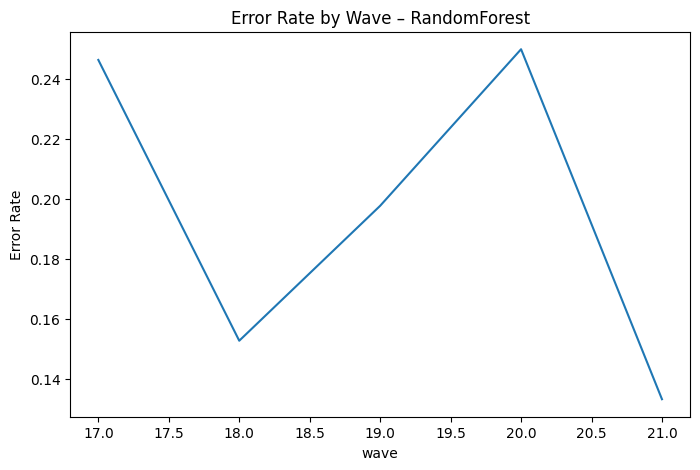

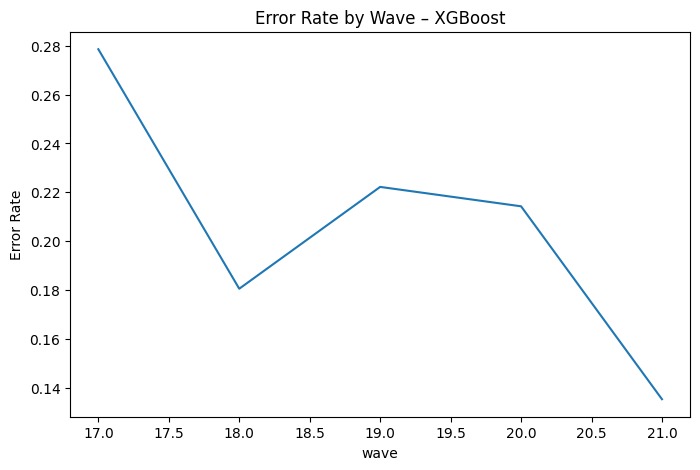

[LightGBM] [Warning] min_data_in_leaf is set=60, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=60
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] min_data_in_leaf is set=60, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=60
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Info] Number of positive: 1098, number of negative: 5426
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.007662 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `f

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] min_data_in_leaf is set=60, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=60
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8


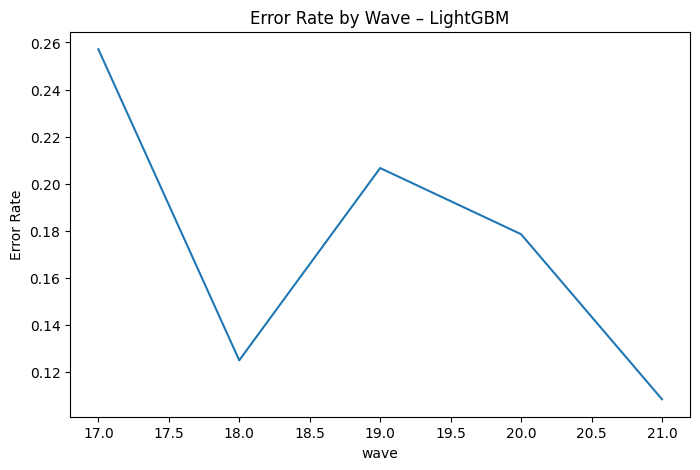

In [ ]:
# Error Analysis by Wave

error_analysis = []

for name, model in models.items():

    pipe = Pipeline([
        ("prep", preprocess),
        ("clf", model)
    ])

    pipe.fit(X_train, y_train)
    probs = pipe.predict_proba(X_test)[:,1]
    preds = (probs >= 0.5).astype(int)

    test_df = X_test.copy()
    test_df["true"] = y_test.values
    test_df["pred"] = preds
    test_df["wave"] = df_model.loc[X_test.index, "wave"]

    test_df["error"] = test_df["true"] != test_df["pred"]

    error_by_wave = test_df.groupby("wave")["error"].mean()

    plt.figure(figsize=(8,5))
    error_by_wave.plot()
    plt.title(f"Error Rate by Wave – {name}")
    plt.ylabel("Error Rate")
    plt.show()


In [ ]:
summary_df = pd.DataFrame({
    "ROC_AUC_Test": test_results,
    "PR_Average_Precision": pr_results,
})

print(summary_df)


              ROC_AUC_Test  PR_Average_Precision
RandomForest      0.801804              0.444699
XGBoost           0.825898              0.489031
LightGBM          0.820076              0.474943


stage 6 - Compare model performance and evaluate accuracy


In [ ]:
#  Model Evaluation (Chronological Test Set)

# Safe MAPE
# Avoid division by zero in percentage error
def safe_mape(y_true, y_pred, eps=1e-9):
    y_true = np.array(y_true).astype(float)
    y_pred = np.array(y_pred).astype(float)
    denom = np.maximum(np.abs(y_true), eps)
    return np.mean(np.abs((y_true - y_pred) / denom)) * 100


# Store predictions and results
model_probabilities = {}
evaluation_results = {}

# Loop over models defined in Stage 4
for name, model in models.items():

    # Create pipeline with preprocessing + classifier
    pipe = Pipeline([
        ("preprocess", preprocess),
        ("classifier", model)
    ])

    # Train only on chronological training set
    pipe.fit(X_train, y_train)

    # Predict probability for match = 1
    probs = pipe.predict_proba(X_test)[:, 1]
    model_probabilities[name] = probs

    #  Evaluation Metrics
    rmse = np.sqrt(mean_squared_error(y_test, probs))
    mae  = mean_absolute_error(y_test, probs)
    mape = safe_mape(y_test, probs)
    r2   = r2_score(y_test, probs)

    evaluation_results[name] = {
        "RMSE": rmse,
        "MAE": mae,
        "MAPE (%)": mape,
        "R2": r2
    }


# Convert results to DataFrame
evaluation_df = pd.DataFrame(evaluation_results).T
evaluation_df = evaluation_df.sort_values("RMSE")

display(evaluation_df)


[LightGBM] [Warning] min_data_in_leaf is set=60, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=60
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] min_data_in_leaf is set=60, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=60
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Info] Number of positive: 1098, number of negative: 5426
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.007842 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `f

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,RMSE,MAE,MAPE (%),R2
LightGBM,0.342697,0.217373,1.450081e+10,0.089379
XGBoost,0.360749,0.264136,1.990629e+10,-0.009087
RandomForest,0.400727,0.381787,3.053295e+10,-0.245131


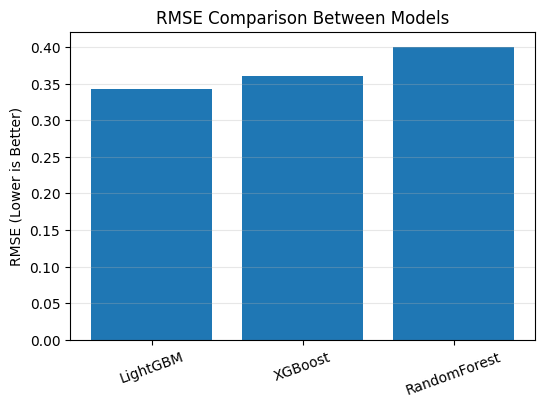

In [ ]:
#RMSE
plt.figure(figsize=(6,4))
plt.bar(evaluation_df.index, evaluation_df["RMSE"])
plt.title("RMSE Comparison Between Models")
plt.ylabel("RMSE (Lower is Better)")
plt.xticks(rotation=20)
plt.grid(axis="y", alpha=0.3)
plt.show()


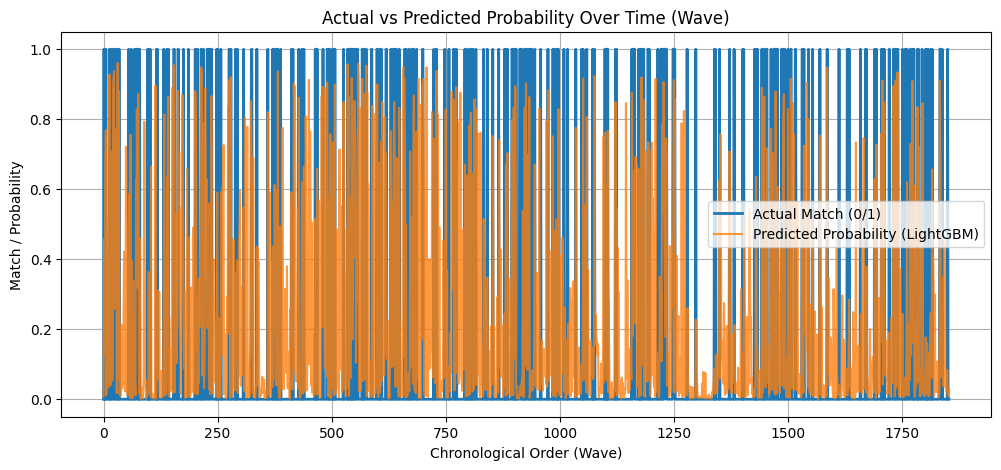

Best performing model according to RMSE: LightGBM


In [ ]:
# Select best model according to RMSE
best_model = evaluation_df.index[0]
best_probs = pd.Series(model_probabilities[best_model], index=X_test.index)

# Ensure chronological order by wave
test_temp = X_test.copy()
test_temp["wave"] = df.loc[X_test.index, "wave"]
test_temp = test_temp.sort_values("wave")

y_test_sorted = y_test.loc[test_temp.index]
best_probs_sorted = best_probs.loc[test_temp.index]

plt.figure(figsize=(12,5))
plt.plot(y_test_sorted.values, label="Actual Match (0/1)", linewidth=2)
plt.plot(best_probs_sorted.values,
         label=f"Predicted Probability ({best_model})",
         alpha=0.8)

plt.title("Actual vs Predicted Probability Over Time (Wave)")
plt.xlabel("Chronological Order (Wave)")
plt.ylabel("Match / Probability")
plt.legend()
plt.grid(True)
plt.show()

print(f"Best performing model according to RMSE: {best_model}")
